# Estudo de caso: peso médio de aves com amostras pequenas

**GCC1625 — Inferência Estatística | Estimação intervalar**

Uma equipe que estuda alimentação de aves quer estimar o peso médio ao final de seis semanas sob uma dieta de farinha de carne (`meatmeal`). Há apenas 11 observações e o desvio padrão populacional é desconhecido. **Qual faixa de valores podemos apresentar para a média e até que ponto as suposições do procedimento são defensáveis?**

O estudo usa os dados locais de [ChickData.csv](../data/ChickData.csv). A dieta de caseína (`casein`, 12 aves) permite repetir a análise. Um contraponto com [salarios.csv](../data/permutation/salarios.csv) mostra um caso em que a normalidade é questionável.

O roteiro acompanha a seção **Estimação Intervalar para Amostras Pequenas** da [Nota de Aula 03](../notas_aula/GCC1625_03_estimacao_intervalar.pdf): dados e contexto → diagnóstico de normalidade → IC com $t$ → interpretação e limites.

Ao final, você deverá conseguir calcular o IC passo a passo, interpretar um Q-Q plot e o teste de Shapiro–Wilk, distinguir desvio padrão de erro-padrão e redigir uma conclusão que explicite as suposições da inferência.

## 1. Por que estes dados?

A escolha considerou tamanho dos grupos, natureza da variável, documentação e unidade observacional. Usaremos todas as observações das dietas disponíveis.

| Arquivo em `data/` | Estrutura observada | Adequação ao objetivo |
|---|---|---|
| `ChickData.csv` | 23 pesos; `meatmeal`: 11; `casein`: 12 | **Caso principal:** grupos naturalmente pequenos, variável quantitativa e origem identificável. |
| `permutation/salarios.csv` | 48 registros; 24 por grupo | **Contraponto:** o grupo B permite discutir cauda direita e a influência de valores elevados. O CSV não documenta moeda, local ou desenho amostral. |
| `permutation/algoritmos.csv` | 60 tempos; 30 por algoritmo | Boa alternativa ligada à computação; os grupos são maiores que os de aves, e o CSV não esclarece o protocolo de medição. |
| `anova/Fertilizante.csv` | 75 registros; 25 por método | Tamanho adequado, mas o cabeçalho genérico `Nota` não informa a unidade da resposta. |
| `CutSenti.csv` | 11 linhas; quatro métodos | Exigiria esclarecer se as linhas são execuções independentes ou avaliações relacionadas; não devemos tratar as quatro colunas como observações independentes. |
| `bootstrap/tempos_api.csv` | 360 requisições; quatro endpoints | Útil para discutir assimetria, mas exigiria uma subamostra para este foco em amostras pequenas. |
| `mtcars.csv`, `Auto.csv`, `survey.csv` | 32, 392 e 237 registros | Exigiriam justificar um recorte, a população-alvo e o mecanismo de seleção; menos diretos para este estudo. |

O contraponto foi escolhido para uma finalidade didática exploratória: mostrar um diagnóstico diferente. Isso não transforma a seleção posterior de um exemplo em uma análise confirmatória previamente planejada.

## 2. Contexto, parâmetro e suposições

Os 23 pares `(weight, feed)` do arquivo local coincidem com os grupos `meatmeal` e `casein` do conjunto **chickwts**, do R. A [documentação oficial de chickwts](https://search.r-project.org/R/refmans/datasets/html/chickwts.html) descreve pesos em **gramas após seis semanas** e alocação aleatória de aves recém-nascidas a dietas. O conjunto original contém outras dietas, que não estão no CSV local. A conferência usou a [cópia pública em CSV](https://vincentarelbundock.github.io/Rdatasets/csv/datasets/chickwts.csv); a execução deste notebook lê somente arquivos locais.

| Elemento | Definição neste estudo |
|---|---|
| Unidade observacional | Uma ave, com um peso final registrado. |
| Variável $X$ | Peso em gramas após seis semanas sob `meatmeal`. |
| Parâmetro principal $\mu$ | Peso médio de aves submetidas a essa dieta em condições comparáveis às do experimento. |
| Estimador | Média amostral $\overline X$. |
| Desvio padrão populacional $\sigma$ | Desconhecido; estimado por $S$. |
| Nível de confiança | 95%, fixado antes dos cálculos. |

Modelaremos os pesos **dentro de cada dieta** como observações independentes de uma mesma população aproximadamente normal. A alocação aleatória a dietas não equivale à seleção aleatória de todas as aves de uma população ampla. O CSV não informa baias, lotes ou possíveis dependências: se aves compartilham fatores que geram correlação, o erro-padrão usual pode ser inadequado. O diagnóstico de normalidade não resolve essa questão.

### 2.1. O que significa “dependência entre aves”?

Aqui, dependência se refere aos **pesos observados**, que podem estar correlacionados porque as aves compartilham fatores que afetam seu crescimento: a mesma baia, condições de temperatura, exposição a doenças ou origem genética.

Imagine que algumas baias sejam mais quentes que outras e que essa diferença afete o crescimento. Os pesos das aves de uma mesma baia podem variar juntos em resposta à temperatura, tornando-se mais parecidos entre si. Nesse caso, observar mais uma ave daquela baia acrescenta menos informação independente sobre a média populacional do que acrescentaria sob a suposição de independência. Ter 11 aves, portanto, não garante ter 11 observações independentes.

Isso importa porque o erro-padrão usado neste estudo,

$$\widehat{\mathrm{EP}}(\overline X)=\frac{s}{\sqrt n},$$

é calculado sob a suposição de observações independentes, com uma mesma variância populacional. Quando há correlação positiva entre os pesos, essa fórmula pode subestimar a incerteza da média e produzir um intervalo de confiança estreito demais. As flutuações compartilhadas pelas aves não se compensam como se compensariam entre observações independentes.

**Normalidade e independência são suposições diferentes.** Mesmo que os pesos apresentem um Q-Q plot aproximadamente linear, isso não demonstra que sejam independentes. Para avaliar a dependência, precisamos conhecer o desenho do estudo: como as aves foram alojadas, quais compartilham uma baia ou um lote e como as dietas foram atribuídas. Se houver agrupamento relevante, a análise deverá levar essa estrutura em conta.

**Não identificamos dependência neste conjunto de dados.** O CSV contém apenas peso e dieta, sem informações sobre baias ou parentesco. Trata-se de uma suposição necessária ao procedimento que não conseguimos verificar com esse arquivo, e não de uma afirmação de que as aves do experimento eram dependentes.


## 3. Preparação e leitura

Execute as células na ordem, usando **Restart Kernel and Run All**. Dependências: `numpy`, `pandas`, `scipy`, `matplotlib` e `ipykernel`. Se necessário, instale-as no ambiente do kernel com `%pip install numpy pandas scipy matplotlib ipykernel` e reinicie-o.

O código localiza `data/` partindo da raiz do projeto ou da pasta `notebooks/`. Para outro diretório de execução, preencha `RAIZ_MANUAL`. Nenhum download é necessário.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

RAIZ_MANUAL = None  # Exemplo: Path('/caminho/para/gcc1625')
if RAIZ_MANUAL is not None:
    RAIZ = Path(RAIZ_MANUAL).expanduser().resolve()
else:
    RAIZ = next(
        (p for p in [Path.cwd(), *Path.cwd().parents]
         if (p / 'data' / 'ChickData.csv').is_file()),
        None,
    )
if RAIZ is None or not (RAIZ / 'data' / 'ChickData.csv').is_file():
    raise FileNotFoundError('Não encontrei data/ChickData.csv. Defina RAIZ_MANUAL.')
DATA = RAIZ / 'data'

CONFIANCA = 0.95
ALFA_NORMALIDADE = 0.05  # Significância do diagnóstico; não é o nível de confiança.
DIETA_PRINCIPAL = 'meatmeal'
DIETAS = ['meatmeal', 'casein']
CORES = {'meatmeal': '#245b8a', 'casein': '#b45d22'}
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})
pd.options.display.float_format = '{:.4f}'.format

display(pd.Series({'Python': sys.version.split()[0], 'NumPy': np.__version__,
                   'pandas': pd.__version__, 'SciPy': scipy.__version__,
                   'Matplotlib': matplotlib.__version__}, name='Versão'))

Python        3.12.7
NumPy         1.26.4
pandas         2.2.3
SciPy         1.13.1
Matplotlib     3.9.2
Name: Versão, dtype: object

In [2]:
aves = pd.read_csv(DATA / 'ChickData.csv')
if set(aves.columns) != {'weight', 'feed'}:
    raise ValueError('Esquema inesperado no CSV de aves.')
aves['weight'] = pd.to_numeric(aves['weight'], errors='raise')
if aves[['weight', 'feed']].isna().any().any():
    raise ValueError('Há valores ausentes; investigue-os antes de continuar.')
if not np.isfinite(aves['weight']).all() or (aves['weight'] <= 0).any():
    raise ValueError('Há pesos não finitos ou não positivos.')
if set(aves['feed']) != set(DIETAS):
    raise ValueError('Dietas diferentes das previstas neste estudo.')

# Identificador da linha de dados, criado para a análise; não é um ID original da ave.
aves.insert(0, 'registro', np.arange(1, len(aves) + 1))
display(aves)
display(aves.groupby('feed')['weight'].agg(n='size', minimo='min', maximo='max'))
print('Valores ausentes:', int(aves.isna().sum().sum()))
print('Pares peso/dieta repetidos:', int(aves.duplicated(['weight', 'feed']).sum()))

,registro,weight,feed
0,1,325,meatmeal
1,2,257,meatmeal
2,3,303,meatmeal
3,4,315,meatmeal
4,5,380,meatmeal
5,6,153,meatmeal
6,7,263,meatmeal
7,8,242,meatmeal
8,9,206,meatmeal
9,10,344,meatmeal


,n,minimo,maximo
feed,,,
casein,12,216,404
meatmeal,11,153,380


Valores ausentes: 0
Pares peso/dieta repetidos: 0


Os dados locais têm 11 aves em `meatmeal` e 12 em `casein`, sem pesos ausentes. Preservamos todas as linhas. Mesmo que duas aves tivessem o mesmo peso, isso não justificaria deduplicar o arquivo: valores iguais podem pertencer a unidades diferentes.

**Antes de calcular:** por que 23 não é o tamanho amostral do IC da média sob `meatmeal`? Porque apenas 11 observações correspondem à população definida para esse parâmetro.

## 4. Exploração: centro, dispersão e valores extremos

Primeiro olhamos os dados individuais. Um histograma com 11 ou 12 valores depende bastante dos limites das classes; por isso, o acompanhamos de pontos e boxplot. A regra de $1{,}5\,\mathrm{IQR}$ sinaliza observações para investigação, **não** determina automaticamente erros ou exclusões.

,n,media,mediana,s,minimo,maximo,erro_padrao,assimetria_amostral
feed,,,,,,,,
meatmeal,11,276.9091,263.0000,64.9006,153,380,19.5683,-0.3295
casein,12,323.5833,342.0000,64.4338,216,404,18.6004,-0.6030


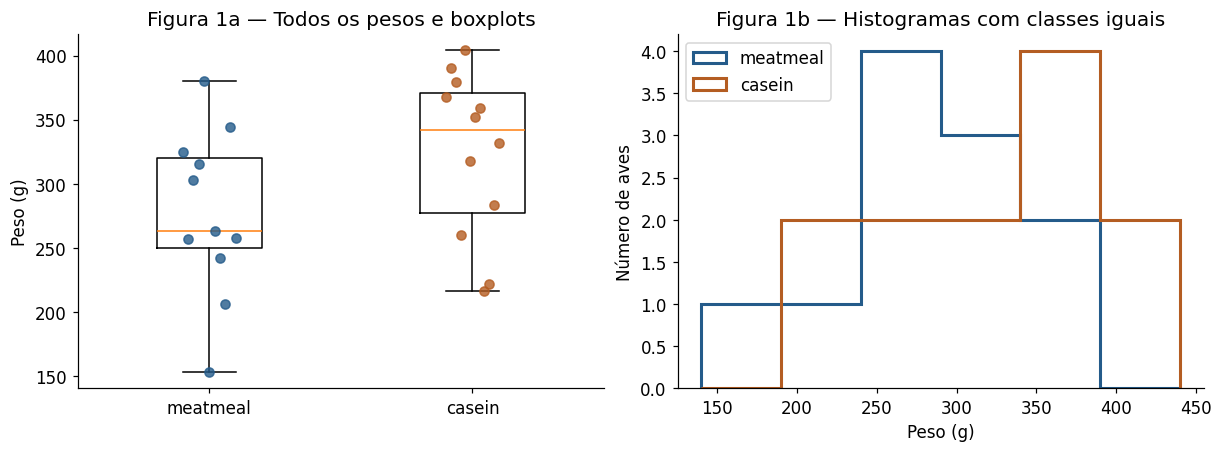

,limite_inferior,limite_superior,sinalizados
dieta,,,
meatmeal,143.7500,425.7500,0
casein,137.0000,511.0000,0


In [3]:
resumo = aves.groupby('feed')['weight'].agg(
    n='size', media='mean', mediana='median', s='std', minimo='min', maximo='max'
).reindex(DIETAS)
resumo['erro_padrao'] = resumo['s'] / np.sqrt(resumo['n'])
resumo['assimetria_amostral'] = [
    stats.skew(aves.loc[aves.feed == dieta, 'weight'], bias=False) for dieta in DIETAS
]
display(resumo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
for i, dieta in enumerate(DIETAS):
    valores = aves.loc[aves.feed == dieta, 'weight'].to_numpy()
    axes[0].boxplot(valores, positions=[i], widths=0.4, showfliers=False)
    # Deslocamento apenas visual, determinístico; todos os pesos são preservados.
    axes[0].scatter(i + np.linspace(-0.1, 0.1, len(valores)), valores,
                    color=CORES[dieta], alpha=0.8, zorder=3)
    axes[1].hist(valores, bins=np.arange(140, 441, 50), histtype='step',
                 linewidth=2, color=CORES[dieta], label=dieta)
axes[0].set(xticks=range(2), xticklabels=DIETAS, ylabel='Peso (g)',
            title='Figura 1a — Todos os pesos e boxplots')
axes[1].set(xlabel='Peso (g)', ylabel='Número de aves',
            title='Figura 1b — Histogramas com classes iguais')
axes[1].legend()
plt.show()

limites_iqr = []
for dieta in DIETAS:
    valores = aves.loc[aves.feed == dieta, 'weight']
    q1, q3 = valores.quantile([0.25, 0.75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    limites_iqr.append({'dieta': dieta, 'limite_inferior': inferior,
                        'limite_superior': superior,
                        'sinalizados': int(((valores < inferior) | (valores > superior)).sum())})
display(pd.DataFrame(limites_iqr).set_index('dieta'))

Na Figura 1, os pesos de `casein` se concentram em valores mais elevados, embora exista sobreposição entre os grupos. As dispersões amostrais são próximas, cerca de 65 g. Em `casein`, a média (323,58 g) é menor que a mediana (342 g), sugerindo alguma assimetria à esquerda. Em `meatmeal`, a média (276,91 g) é maior que a mediana (263 g), embora o coeficiente de assimetria seja ligeiramente negativo. Esses resumos captam aspectos diferentes da forma e são instáveis em amostras pequenas; o diagnóstico deve considerar também os gráficos.

Nenhum peso é sinalizado pela regra de $1{,}5\,\mathrm{IQR}$. Isso não prova normalidade. Para `meatmeal`, $s$ descreve a dispersão dos **pesos individuais**, enquanto $s/\sqrt n$ estima a dispersão da **média amostral** em repetições do estudo. Essas quantidades têm a mesma unidade, mas significados diferentes.

## 5. Verificação da suposição de normalidade

### 5.1. Q-Q plots

O Q-Q plot compara pesos ordenados com quantis de uma normal padrão. Para uma população normal com média e desvio padrão quaisquer, esperamos alinhamento aproximado em uma reta, não necessariamente na reta de 45°. Curvatura sistemática e afastamentos nos extremos merecem atenção.

Examinamos **os pesos dentro de cada dieta**, e não a distribuição de um conjunto de médias simuladas. A função [`scipy.stats.probplot`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html), usada na nota de aula, produz o gráfico de probabilidades normal empregado aqui como diagnóstico Q-Q.

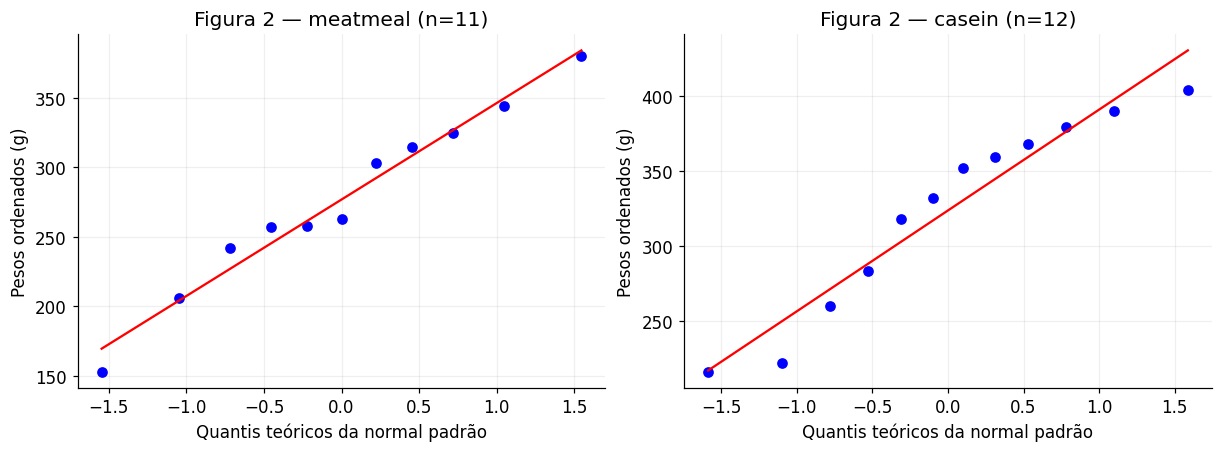

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
for ax, dieta in zip(axes, DIETAS):
    valores = aves.loc[aves.feed == dieta, 'weight'].to_numpy()
    stats.probplot(valores, dist='norm', plot=ax)
    ax.set(title=f'Figura 2 — {dieta} (n={len(valores)})',
           xlabel='Quantis teóricos da normal padrão', ylabel='Pesos ordenados (g)')
    ax.grid(alpha=0.2)
plt.show()

Na Figura 2, `meatmeal` apresenta alinhamento aproximadamente linear. Em `casein`, há desvios mais visíveis, compatíveis com a assimetria à esquerda observada anteriormente. Com apenas 11 ou 12 pontos, alguma irregularidade é esperada; não devemos exigir alinhamento perfeito nem descartar os extremos para melhorar o gráfico.

### 5.2. Shapiro–Wilk

Para cada dieta, o teste considera $H_0$: a população dos pesos é normal; $H_1$: ela não é normal. Fixamos significância de 5%. Um p-valor pequeno indica evidência contra $H_0$; um p-valor alto indica que o teste **não detectou evidência suficiente contra ela**.

O p-valor não é a probabilidade de a população ser normal. Amostras pequenas oferecem pouco poder para detectar certos desvios. Não usaremos o teste como uma chave automática que garante ou proíbe o IC: contexto, independência, Q-Q plot e valores extremos também entram na avaliação. Implementação: [`scipy.stats.shapiro`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html).

In [5]:
diagnosticos = []
for dieta in DIETAS:
    valores = aves.loc[aves.feed == dieta, 'weight'].to_numpy()
    resultado = stats.shapiro(valores)
    diagnosticos.append({'dieta': dieta, 'n': len(valores), 'W': resultado.statistic,
                         'p_valor': resultado.pvalue,
                         'evidencia_contra_normalidade_5pct': resultado.pvalue < ALFA_NORMALIDADE})
normalidade = pd.DataFrame(diagnosticos).set_index('dieta')
display(normalidade)

,n,W,p_valor,evidencia_contra_normalidade_5pct
dieta,,,,
meatmeal,11,0.9791,0.9612,False
casein,12,0.9166,0.2592,False


### 5.3. Decisão fundamentada

Para `meatmeal`, obtemos $p\approx0{,}9612$; para `casein`, $p\approx0{,}2592$. Nenhum dos testes rejeita a normalidade a 5%. Somados ao Q-Q plot e à ausência de valores extremos sinalizados, os resultados tornam o modelo normal uma **aproximação de trabalho plausível**, sobretudo no grupo principal. Os desvios em `casein` recomendam mais cautela.

Prosseguiremos com o IC com $t$, explicitamente condicionado à independência e à adequação desse modelo. Não afirmaremos que a normalidade foi comprovada nem que a cobertura real foi medida. A cobertura exata de 95% é uma propriedade do procedimento sob observações i.i.d. normais; fora dessas condições, pode ser apenas aproximada.

## 6. IC de 95% para o peso médio sob `meatmeal`

Com $\sigma$ desconhecido e observações i.i.d. normais,

$$T=\frac{\overline X-\mu}{S/\sqrt n}\sim t_{n-1}.$$

Aplicamos os quatro passos da nota de aula:

$$\overline x=\frac1n\sum_i x_i,\qquad
s=\sqrt{\frac{\sum_i(x_i-\overline x)^2}{n-1}},\qquad
t^*=t_{n-1,\,\alpha/2},\qquad
IC=\left[\overline x-t^*\frac{s}{\sqrt n},\ \overline x+t^*\frac{s}{\sqrt n}\right].$$

Na notação da nota, $t_{n-1,\,\alpha/2}$ deixa $\alpha/2$ na cauda **direita**. Em Python, a função de quantis recebe a probabilidade acumulada à **esquerda**: `stats.t.ppf(1 - alpha/2, df=n-1)`. Para 95%, usamos `0.975`, e não `0.95`.

No exemplo abaixo, usamos `np.std(x, ddof=1)` para calcular $s$. O parâmetro **`ddof`** é abreviação de **Delta Degrees of Freedom** (“diferença nos graus de liberdade”) e indica quanto subtrair de $n$ no denominador do cálculo da variância:

$$\text{denominador}=n-\texttt{ddof}.$$

- `ddof=0` (padrão de `np.std`): divide a soma dos desvios quadráticos por $n$.
- `ddof=1`: divide por $n-1$, como na variância amostral $s^2$ usada neste estudo.

A função `np.std` calcula a raiz quadrada dessa variância, obtendo o desvio padrão. Usamos `ddof=1` porque a média foi estimada com os próprios dados: os resíduos $x_i-\overline x$ somam zero, restando $n-1$ graus de liberdade. Essa correção torna $s^2$ um estimador não viesado da variância populacional sob observações i.i.d. com variância finita; ela não torna, em geral, $s$ um estimador não viesado de $\sigma$.


In [6]:
x = aves.loc[aves.feed == DIETA_PRINCIPAL, 'weight'].to_numpy(dtype=float)
n = len(x)
media = np.mean(x)
s = np.std(x, ddof=1)  # Divisor n - 1.
gl = n - 1
alfa_ic = 1 - CONFIANCA
t_critico = stats.t.ppf(1 - alfa_ic / 2, df=gl)
erro_padrao = s / np.sqrt(n)
margem = t_critico * erro_padrao
limite_inferior = media - margem
limite_superior = media + margem

display(pd.Series({
    'n': n, 'graus de liberdade': gl, 'média (g)': media,
    's (g)': s, 'erro-padrão (g)': erro_padrao, 't crítico': t_critico,
    'margem de erro (g)': margem, 'limite inferior (g)': limite_inferior,
    'limite superior (g)': limite_superior,
}, name='Cálculo passo a passo').to_frame())

# Conferência independente com a função pronta da SciPy.
ic_scipy = stats.t.interval(CONFIANCA, df=gl, loc=media, scale=stats.sem(x))
np.testing.assert_allclose([limite_inferior, limite_superior], ic_scipy)
display(Markdown(
    f'**IC de {CONFIANCA:.0%}: [{limite_inferior:.2f}; {limite_superior:.2f}] g.** '
    f'O cálculo é {media:.2f} ± {margem:.2f} g.'
))

,Cálculo passo a passo
n,11.0000
graus de liberdade,10.0000
média (g),276.9091
s (g),64.9006
erro-padrão (g),19.5683
t crítico,2.2281
margem de erro (g),43.6008
limite inferior (g),233.3083
limite superior (g),320.5099


**IC de 95%: [233.31; 320.51] g.** O cálculo é 276.91 ± 43.60 g.

O resultado é aproximadamente **[233,31; 320,51] g**, com média amostral de **276,91 g**, erro-padrão de **19,57 g** e margem de erro de **43,60 g**.

**Interpretação contextual:** sob as suposições adotadas, estimamos com 95% de confiança que o peso médio de aves submetidas a `meatmeal` em condições comparáveis esteja entre 233,31 e 320,51 g. Se repetíssemos o procedimento sob o modelo, cerca de 95% dos intervalos conteriam a média populacional fixa.

O intervalo não afirma que 95% das aves pesam entre esses limites, não é um intervalo de previsão para uma nova ave e não atribui probabilidade de 95% a $\mu$ depois de observar os dados.

### 6.1. Por que usar $t$? E se quisermos maior confiança?

O uso de $S$ no lugar de $\sigma$ introduz incerteza. A distribuição $t$ acomoda essa incerteza com um valor crítico maior. Vamos comparar $t$ e a aproximação com $z$ usando exatamente os mesmos dados, e construir ICs de 90%, 95% e 99%.

,confianca,metodo,critico,margem_g,inferior_g,superior_g
0,0.9000,t,1.8125,35.4667,241.4424,312.3758
1,0.9000,z com s (aproximação),1.6449,32.1869,244.7221,309.0960
2,0.9500,t,2.2281,43.6008,233.3083,320.5099
3,0.9500,z com s (aproximação),1.9600,38.3531,238.5560,315.2622
4,0.9900,t,3.1693,62.0172,214.8919,338.9263
5,0.9900,z com s (aproximação),2.5758,50.4045,226.5046,327.3136


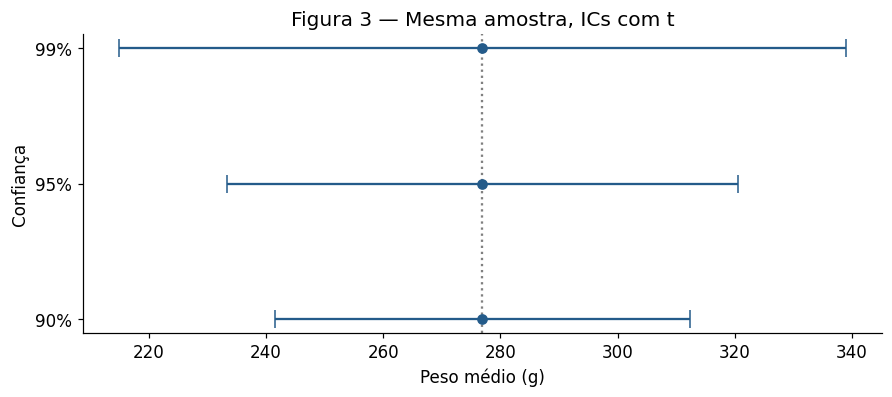

Em 95%, a margem com t é 13.7% maior que com z.


In [7]:
comparacao = []
for confianca in [0.90, 0.95, 0.99]:
    q = (1 + confianca) / 2
    for metodo, critico in [('t', stats.t.ppf(q, gl)), ('z com s (aproximação)', stats.norm.ppf(q))]:
        e = critico * erro_padrao
        comparacao.append({'confianca': confianca, 'metodo': metodo, 'critico': critico,
                            'margem_g': e, 'inferior_g': media - e, 'superior_g': media + e})
comparacao = pd.DataFrame(comparacao)
display(comparacao)

somente_t = comparacao.loc[comparacao.metodo == 't']
fig, ax = plt.subplots(figsize=(8, 3.5), layout='constrained')
ax.errorbar(np.repeat(media, len(somente_t)), np.arange(len(somente_t)),
            xerr=somente_t.margem_g.to_numpy(), fmt='o', capsize=6, color=CORES['meatmeal'])
ax.axvline(media, ls=':', color='gray')
ax.set(yticks=range(3), yticklabels=['90%', '95%', '99%'], xlabel='Peso médio (g)',
       ylabel='Confiança', title='Figura 3 — Mesma amostra, ICs com t')
plt.show()
print(f'Em 95%, a margem com t é {100 * (t_critico / stats.norm.ppf(0.975) - 1):.1f}% maior que com z.')

Na Figura 3, todos os intervalos têm o mesmo centro. Aumentar a confiança alarga o intervalo: não significa que coletamos mais informação. Com 95% de confiança e 10 graus de liberdade, $t^*\approx2{,}228$ é maior que $z^*\approx1{,}960$; a margem com $t$ é aproximadamente 13,7% maior.

O tamanho 30 não é uma fronteira matemática entre $z$ e $t$. Quando $\sigma$ é desconhecido, $t$ continua sendo a referência sob normalidade, inclusive para amostras maiores.

## 7. Replicação na dieta `casein`

Agora encapsulamos os mesmos cálculos e usamos as 12 observações de `casein`. Os intervalos serão **individuais**, cada um com nível nominal de 95%; não constituem uma região de confiança conjunta de 95% nem um IC para a diferença de médias.

,n,media,s,gl,ep,t_critico,margem,inferior,superior
dieta,,,,,,,,,
meatmeal,11.0000,276.9091,64.9006,10.0000,19.5683,2.2281,43.6008,233.3083,320.5099
casein,12.0000,323.5833,64.4338,11.0000,18.6004,2.2010,40.9393,282.6440,364.5226


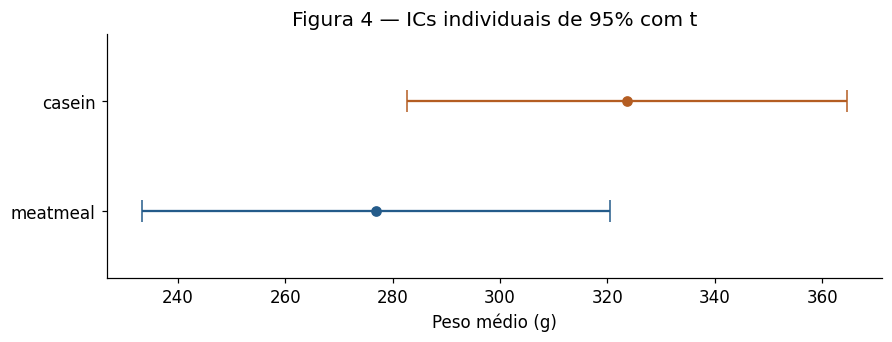

In [8]:
def ic_media_t(valores, confianca=0.95):
    """IC bilateral para uma média; validade depende das suposições discutidas."""
    valores = np.asarray(valores, dtype=float)
    if valores.ndim != 1 or valores.size < 2 or not np.isfinite(valores).all():
        raise ValueError('Forneça um vetor com pelo menos dois valores finitos.')
    if not 0 < confianca < 1:
        raise ValueError('A confiança deve estar entre 0 e 1.')
    n = valores.size
    media = valores.mean()
    s = valores.std(ddof=1)
    ep = s / np.sqrt(n)
    critico = stats.t.ppf((1 + confianca) / 2, df=n - 1)
    margem = critico * ep
    return {'n': n, 'media': media, 's': s, 'gl': n - 1, 'ep': ep,
            't_critico': critico, 'margem': margem,
            'inferior': media - margem, 'superior': media + margem}

intervalos = pd.DataFrame({
    dieta: ic_media_t(aves.loc[aves.feed == dieta, 'weight'], CONFIANCA)
    for dieta in DIETAS
}).T
intervalos.index.name = 'dieta'
display(intervalos)

for dieta in DIETAS:
    valores = aves.loc[aves.feed == dieta, 'weight'].to_numpy()
    referencia = stats.t.interval(CONFIANCA, len(valores) - 1,
                                   loc=valores.mean(), scale=stats.sem(valores))
    np.testing.assert_allclose(intervalos.loc[dieta, ['inferior', 'superior']], referencia)

fig, ax = plt.subplots(figsize=(8, 3), layout='constrained')
for i, dieta in enumerate(DIETAS):
    r = intervalos.loc[dieta]
    ax.errorbar(r['media'], i, xerr=r['margem'], fmt='o', capsize=7,
                color=CORES[dieta], label=dieta)
ax.set(yticks=range(2), yticklabels=DIETAS, xlabel='Peso médio (g)',
       title='Figura 4 — ICs individuais de 95% com t')
ax.set_ylim(-0.6, 1.6)
plt.show()

Para `casein`, a média é **323,58 g** e o IC de 95% é aproximadamente **[282,64; 364,52] g**. A Figura 4 apresenta a incerteza sobre cada média. A maior média amostral de `casein` não basta para concluir que a dieta causa maior peso.

Não usaremos a sobreposição dos ICs como teste de igualdade das médias. Essa seria outra pergunta inferencial, que exigiria um procedimento específico para a diferença, além da análise do desenho experimental.

## 8. Sensibilidade: quanto uma observação influencia o resultado?

Com $n$ pequeno, cada ave tem peso importante no cálculo. Retiraremos **uma observação por vez**, apenas como diagnóstico, para observar a mudança na média e nos limites do IC de `meatmeal`. Os resultados dependentes entre si não são novas amostras independentes nem uma estimativa da cobertura. O IC principal continuará usando todas as 11 aves.

In [9]:
principal = aves.loc[aves.feed == DIETA_PRINCIPAL].reset_index(drop=True)
sensibilidade = []
for i, registro in principal.iterrows():
    r = ic_media_t(principal.drop(index=i)['weight'], CONFIANCA)
    sensibilidade.append({'registro_retirado': int(registro['registro']),
                           'peso_retirado_g': registro['weight'],
                           'media_g': r['media'], 'variacao_media_g': r['media'] - media,
                           'inferior_g': r['inferior'], 'superior_g': r['superior']})
sensibilidade = pd.DataFrame(sensibilidade)
display(sensibilidade.sort_values('peso_retirado_g'))
print(f'Maior mudança absoluta na média: {sensibilidade.variacao_media_g.abs().max():.2f} g.')
print(f'Margem de erro com todas as aves: {margem:.2f} g.')

,registro_retirado,peso_retirado_g,media_g,variacao_media_g,inferior_g,superior_g
5,6,153,289.3000,12.3909,251.4228,327.1772
8,9,206,284.0000,7.0909,238.3876,329.6124
7,8,242,280.4000,3.4909,232.2466,328.5534
1,2,257,278.9000,1.9909,230.2155,327.5845
10,11,258,278.8000,1.8909,230.0906,327.5094
6,7,263,278.3000,1.3909,229.4853,327.1147
2,3,303,274.3000,-2.6091,225.7985,322.8015
3,4,315,273.1000,-3.8091,225.0977,321.1023
0,1,325,272.1000,-4.8091,224.6624,319.5376
9,10,344,270.2000,-6.7091,224.2278,316.1722


Maior mudança absoluta na média: 12.39 g.
Margem de erro com todas as aves: 43.60 g.


A maior alteração da média ocorre ao retirar o peso de 153 g: a média aumenta aproximadamente 12,39 g. Isso mostra influência, mas não identifica um erro de medição. A observação não foi sinalizada pela regra do boxplot e não há justificativa documental para removê-la.

Uma decisão sobre exclusão deve investigar o registro e o protocolo. Excluir valores apenas para aumentar o p-valor de Shapiro ou estreitar o IC mudaria a análise em função do resultado desejado.

## 9. Contraponto: uma amostra pequena com cauda direita

O arquivo `data/permutation/salarios.csv` contém `id`, `grupo` e `salario`, com 24 registros em cada grupo. Usaremos **todo o grupo B**, sem procurar uma subamostra que rejeite normalidade. O CSV não documenta moeda, país, período ou seleção dos participantes; por isso, reportamos **unidades monetárias** e tratamos a inferência como exercício condicionado a um modelo, sem afirmar representatividade.

O parâmetro de interesse permanece a **média aritmética** dos salários de uma população que o grupo B pudesse representar. Antes de aplicar a mesma fórmula, examinamos os dados.

,id,grupo,salario
28,29,B,2870.3000
42,43,B,3033.2800
40,41,B,3119.5600
34,35,B,3153.3400
36,37,B,3174.1000
27,28,B,3318.3900
44,45,B,3429.2300
39,40,B,3515.5000
45,46,B,3575.4800
41,42,B,3667.2300


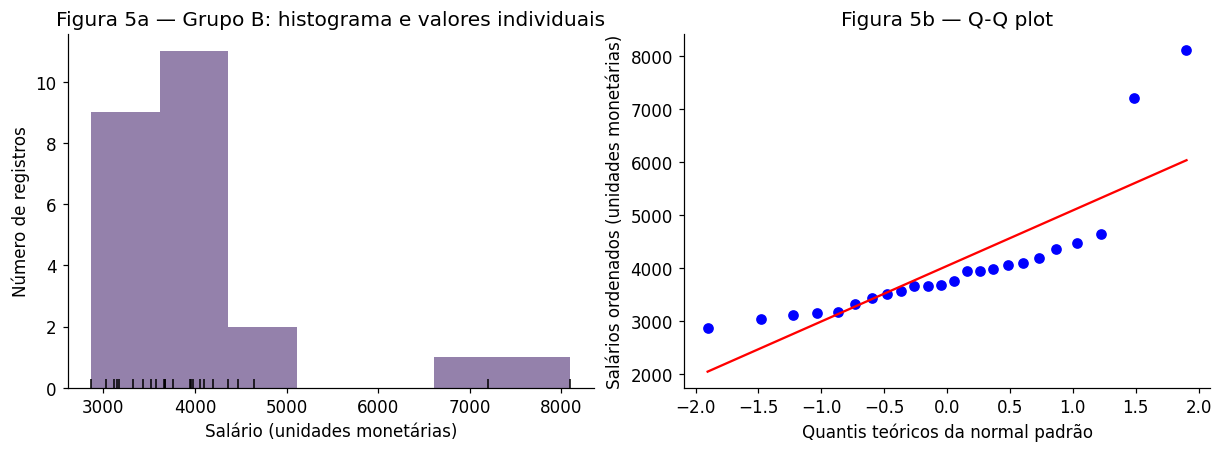

,Grupo B
n,24.0000
media,4040.0608
mediana,3716.0400
assimetria_amostral,2.4763
W,0.6973
p_valor,0.0000
IC_t_inferior_calculo_mecanico,3528.1149
IC_t_superior_calculo_mecanico,4552.0068


Shapiro–Wilk: p = 9.287e-06


In [10]:
salarios = pd.read_csv(DATA / 'permutation' / 'salarios.csv')
salarios['salario'] = pd.to_numeric(salarios['salario'], errors='raise')
grupo_b = salarios.loc[salarios['grupo'] == 'B'].copy()
if len(grupo_b) < 3 or grupo_b['id'].duplicated().any():
    raise ValueError('Verifique o tamanho amostral e os identificadores do grupo B.')
y = grupo_b['salario'].to_numpy(dtype=float)
if not np.isfinite(y).all() or (y <= 0).any():
    raise ValueError('Há salários ausentes, não finitos ou não positivos.')
display(grupo_b.sort_values('salario'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
axes[0].hist(y, bins=7, color='#71578f', alpha=0.75)
axes[0].plot(y, np.zeros_like(y), '|', color='black', markersize=12)
axes[0].set(xlabel='Salário (unidades monetárias)', ylabel='Número de registros',
            title='Figura 5a — Grupo B: histograma e valores individuais')
stats.probplot(y, dist='norm', plot=axes[1])
axes[1].set(xlabel='Quantis teóricos da normal padrão',
            ylabel='Salários ordenados (unidades monetárias)', title='Figura 5b — Q-Q plot')
plt.show()

shapiro_b = stats.shapiro(y)
ic_b = ic_media_t(y, CONFIANCA)
display(pd.Series({'n': len(y), 'media': y.mean(), 'mediana': np.median(y),
                   'assimetria_amostral': stats.skew(y, bias=False),
                   'W': shapiro_b.statistic, 'p_valor': shapiro_b.pvalue,
                   'IC_t_inferior_calculo_mecanico': ic_b['inferior'],
                   'IC_t_superior_calculo_mecanico': ic_b['superior']},
                  name='Grupo B').to_frame())
print(f'Shapiro–Wilk: p = {shapiro_b.pvalue:.3e}')

Na Figura 5, a cauda direita é longa e os maiores salários se afastam da reta no Q-Q plot. Shapiro–Wilk fornece $p\approx9{,}29\times10^{-6}$, evidência contra normalidade; a assimetria amostral é aproximadamente 2,48. Os diagnósticos concordam.

A fórmula com $t$ ainda produz números, mas **a justificativa de cobertura exata sob normalidade não se aplica**. Com 24 registros e assimetria acentuada, não apresentaremos esse cálculo como um IC de cobertura garantida de 95%. Rejeitar normalidade não mede diretamente o erro de cobertura, mas aqui há também uma razão visual e substantiva para cautela. Portanto, nessas condições, não temos justificativa suficiente para recomendar o IC com $t$ como uma aproximação confiável de um intervalo com 95% de cobertura.

## 10. Relatório final do estudo principal

> Foram analisados os pesos de 11 aves da dieta `meatmeal`, registrados em gramas após seis semanas. A média amostral foi 276,91 g e o desvio padrão amostral foi 64,90 g. O Q-Q plot mostrou alinhamento aproximadamente linear e o teste de Shapiro–Wilk não detectou evidência contra normalidade ($W=0{,}9791$; $p=0{,}9612$). Esses resultados são compatíveis com o uso da normal como aproximação de trabalho, sem comprovar essa suposição. Assumindo observações independentes e condições comparáveis às do experimento, o IC de 95% com $t_{10}$ para o peso médio é [233,31; 320,51] g. A margem de erro é 43,60 g. A pequena amostra e a falta de informações sobre dependência entre aves limitam a inferência e sua generalização. Todas as observações foram mantidas.

No grupo `casein`, o mesmo procedimento fornece [282,64; 364,52] g, sob as mesmas ressalvas. O caso de salários evidencia por que executar a fórmula e justificar sua aplicação são etapas diferentes.

## 11. Questões para discussão

1. Qual é a unidade observacional? O que mudaria se houvesse três pesagens de cada ave?
2. Por que usamos `ddof=1` e 10 graus de liberdade no caso principal?
3. Por que remover 153 g só para melhorar o diagnóstico seria inadequado?
4. Refaça o IC principal com 99% de confiança. Qual quantidade muda? Interprete a perda de precisão.
5. Se duas aves compartilham uma baia e seus pesos são correlacionados, um Q-Q plot linear resolve o problema?
6. A sobreposição dos ICs das dietas demonstra igualdade de médias?

<details>
<summary>Comentários para conferência</summary>

1. A ave. Pesagens repetidas da mesma ave não são novas unidades independentes; seria necessário definir a resposta por ave ou modelar a dependência.
2. O desvio padrão amostral usa divisor $n-1$; estimar a média impõe a restrição de soma dos resíduos igual a zero.
3. Não há evidência de erro no registro; a escolha orientada pelo resultado distorce o procedimento.
4. Aumenta o valor crítico e, com ele, a margem; a média e o erro-padrão não mudam. Consulte a tabela da seção 6.1.
5. Não. Normalidade marginal e independência são suposições distintas.
6. Não. É preciso analisar a diferença com um procedimento apropriado, a ser estudado mais adiante.
</details>

## Referências e continuidade

- [Nota de Aula 03 — Estimação Intervalar](../notas_aula/GCC1625_03_estimacao_intervalar.pdf), seção sobre amostras pequenas.
- [Prática com a distribuição t](03c_estimacao_intervalar_amostras_pequenas.ipynb), notebook complementar da disciplina.
- [R: chickwts — documentação e desenho do experimento](https://search.r-project.org/R/refmans/datasets/html/chickwts.html).
- [SciPy: distribuição t, quantis e intervalos](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html).
- [SciPy: Shapiro–Wilk](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html).
- [SciPy: gráfico de probabilidades](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html).